# Notebook 02 — Get-Off & Burst Metrics (2025 BDB)

**Inputs:** `outputs/edge_player_play.csv`, `outputs/tracking_clipped.parquet`  
**Goal:** Extract pre-computed get-off time, compute peak burst speed per rush, assembles them into a clean table, one row = one rush attempt (How fast did the edge rusher come off the ball?)

## Imports & Paths

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

PROJECT_ROOT = Path.cwd().parent
OUT_DIR = PROJECT_ROOT / 'outputs'
OUT_DIR.mkdir(parents=True, exist_ok=True)

## Load Inputs

In [2]:
edge_player_play = pd.read_csv(OUT_DIR / "edge_player_play.csv")
tracking_clipped = pd.read_parquet(OUT_DIR / "tracking_clipped.parquet")

print(edge_player_play.shape)
print(tracking_clipped.shape)

(23345, 52)
(5808236, 22)


## Get-Off Time

In [3]:
# Focus on the time it takes to run through the line of scrimmage and the time to pressure as an edge rusher
getoff = edge_player_play[['gameId', 'playId', 'nflId', 'displayName', 
                                       'getOffTimeAsPassRusher', 'timeToPressureAsPassRusher','causedPressure']].copy()

print(getoff.shape)
print(getoff[['getOffTimeAsPassRusher', 'timeToPressureAsPassRusher']].describe())


(23345, 7)
       getOffTimeAsPassRusher  timeToPressureAsPassRusher
count            21518.000000                 2564.000000
mean                 0.911968                    2.870983
std                  0.263128                    0.979497
min                  0.046000                    1.000000
25%                  0.734000                    2.200000
50%                  0.862000                    2.700000
75%                  1.037000                    3.200000
max                  1.999000                   11.600000


## Burst Speed

In [4]:
# only keep tracking rows for edge rushers
rush_keys = edge_player_play[['gameId', 'playId', 'nflId']]
rusher_tracking = tracking_clipped.merge(rush_keys, on=['gameId', 'playId', 'nflId'], how='inner')

# keep only the burst window
burst_window = rusher_tracking[rusher_tracking['frameOffset'] <= 15]

# peak speed per (game, play, player)
burst = burst_window.groupby(['gameId', 'playId', 'nflId'])['s'].max().reset_index()
burst = burst.rename(columns={'s': 'peakBurstSpeed'})

print(burst.shape)
print(burst['peakBurstSpeed'].describe())

(23320, 4)
count    23320.000000
mean         3.912817
std          1.096165
min          0.040000
25%          3.150000
50%          3.940000
75%          4.730000
max          7.870000
Name: peakBurstSpeed, dtype: float64


## Merge & Assemble

In [5]:
getoff_metrics = getoff.merge(burst, on=['gameId', 'playId', 'nflId'], how='left')

print(getoff_metrics.shape)
print(getoff_metrics.isnull().sum())

(23345, 8)
gameId                            0
playId                            0
nflId                             0
displayName                       0
getOffTimeAsPassRusher         1827
timeToPressureAsPassRusher    20781
causedPressure                    0
peakBurstSpeed                   25
dtype: int64


## Validation

In [6]:
print(getoff_metrics[['getOffTimeAsPassRusher', 'peakBurstSpeed']].describe())
print('\nNegative getOff values:', (getoff_metrics['getOffTimeAsPassRusher'] < 0).sum())

       getOffTimeAsPassRusher  peakBurstSpeed
count            21518.000000    23320.000000
mean                 0.911968        3.912817
std                  0.263128        1.096165
min                  0.046000        0.040000
25%                  0.734000        3.150000
50%                  0.862000        3.940000
75%                  1.037000        4.730000
max                  1.999000        7.870000

Negative getOff values: 0


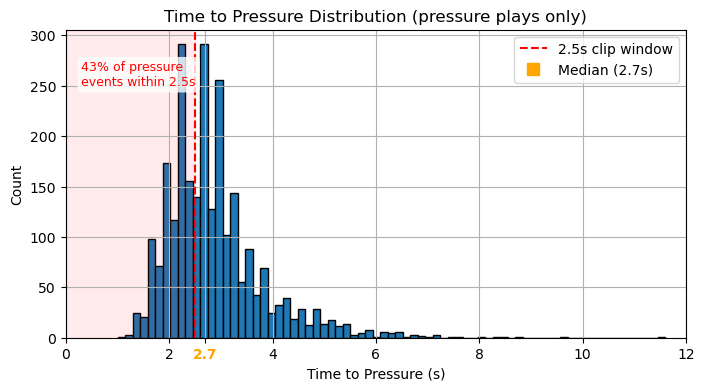

In [7]:
pct_within = (getoff_metrics['timeToPressureAsPassRusher'] <= 2.5).sum() / getoff_metrics['timeToPressureAsPassRusher'].notna().sum()
median_val = getoff_metrics['timeToPressureAsPassRusher'].median()

fig, ax = plt.subplots(figsize=(8, 4))
getoff_metrics['timeToPressureAsPassRusher'].dropna().hist(bins='auto', ax=ax, edgecolor='black')

ax.axvspan(0, 2.5, alpha=0.08, color='red')
ax.axvline(x=2.5, color='red', linestyle='--', label='2.5s clip window')

ax.text(0.3, 250, f'{pct_within:.0%} of pressure\nevents within 2.5s',
        color='red', fontsize=9,
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.3'))

tick_values = [0, 2, 4, 6, 8, 10, 12] + [median_val]
tick_labels = ['0', '2', '4', '6', '8', '10', '12', f'{median_val:.1f}']
ax.set_xticks(tick_values)
ax.set_xticklabels(tick_labels)
ax.get_xticklabels()[-1].set_color('orange')
ax.get_xticklabels()[-1].set_fontweight('bold')

median_handle = Line2D([0], [0], color='orange', linewidth=0, marker='s',
                       markersize=8, label=f'Median ({median_val:.1f}s)')
ax.legend(handles=[ax.get_legend_handles_labels()[0][0], median_handle])

ax.set_xlabel('Time to Pressure (s)')
ax.set_ylabel('Count')
ax.set_title('Time to Pressure Distribution (pressure plays only)')
ax.set_xlim(0, 12)
plt.show()

In [8]:
player_summary = getoff_metrics.groupby('displayName').agg(
    rushes = ('causedPressure', 'count'),
    pressure_rate = ('causedPressure', 'mean'),
    getoff_mean = ('getOffTimeAsPassRusher', 'mean'),
    burst_mean = ('peakBurstSpeed', 'mean')
).reset_index()

# look up players (comment to see first 5 and last 5 rows of summary)
# player_summary[player_summary['rushes'] >= 30].sort_values('getoff_mean').head(5)
# player_summary[player_summary['rushes'] >= 30].sort_values('getoff_mean').tail(5)

# Slow get-off group contains some non-edge players (e.g. Michael Brockers DT, Jamin Davis ILB)
# due to loose roster position labels in players.csv — known limitation of position-based filtering

## Save Output

In [9]:
getoff_metrics.to_csv(OUT_DIR / 'getoff_metrics.csv', index=False)

print(getoff_metrics.shape)
print(f'Unique rushers: {getoff_metrics["nflId"].nunique()}')
print(f'Columns: {getoff_metrics.columns.tolist()}')

(23345, 8)
Unique rushers: 253
Columns: ['gameId', 'playId', 'nflId', 'displayName', 'getOffTimeAsPassRusher', 'timeToPressureAsPassRusher', 'causedPressure', 'peakBurstSpeed']
